# Árboles de Decisión y Random Forest

En este cuaderno vamos a trabajar con dos modelos de aprendizaje supervisado que están muy relacionados entre sí: los **Árboles de Decisión** y los **Random Forest**.

Primero estudiaremos cómo funciona un árbol de decisión individual. Veremos que este tipo de modelo toma decisiones mediante una secuencia de preguntas o reglas, hasta llegar a una clasificación final. También analizaremos una de sus principales ventajas: su facilidad de interpretación y visualización.

Luego veremos que los árboles de decisión, aunque son muy claros y útiles, pueden tener un problema importante: si crecen demasiado, pueden ajustarse en exceso a los datos de entrenamiento. Este fenómeno se conoce como **sobreajuste** u **overfitting**.

A partir de esa limitación, introduciremos el modelo **Random Forest**, que combina muchos árboles de decisión para construir un modelo más robusto. La idea central será pasar de un único árbol a un bosque de árboles, donde cada árbol aporta una predicción y el modelo final decide por votación.

Durante el recorrido vamos a entrenar modelos, visualizar árboles, evaluar resultados con métricas conocidas y comparar el comportamiento de un árbol individual con el de un bosque aleatorio.


## Objetivos del cuaderno

Al finalizar este cuaderno, se espera que puedas:

- Comprender la lógica general de un **Árbol de Decisión**.
- Reconocer los elementos principales de un árbol: nodo raíz, nodos internos, ramas, hojas y profundidad.
- Entrenar un modelo usando `DecisionTreeClassifier`.
- Visualizar un árbol de decisión con `plot_tree`.
- Evaluar el rendimiento de un árbol usando métricas conocidas.
- Analizar el problema del **sobreajuste** en árboles demasiado profundos.
- Comprender la idea general de un **Random Forest** como combinación de muchos árboles.
- Entrenar y evaluar un modelo usando `RandomForestClassifier`.
- Comparar el rendimiento de un árbol individual con el de un bosque aleatorio.
- Interpretar la importancia de las variables dentro de un Random Forest.

## Dataset que vamos a utilizar

Para este cuaderno vamos a utilizar el dataset **Breast Cancer Wisconsin**, incluido dentro de la librería `scikit-learn`.

Este conjunto de datos contiene mediciones realizadas sobre tumores mamarios y tiene como objetivo clasificar cada caso en una de dos categorías posibles: **benigno** o **maligno**.

Elegimos este dataset porque es adecuado para trabajar con modelos de clasificación, no requiere descarga externa y ya viene preparado para ser usado desde Python. Esto nos permite concentrarnos en el objetivo principal del cuaderno: comprender cómo funcionan los Árboles de Decisión y cómo esa idea se extiende al modelo Random Forest.

A lo largo del cuaderno usaremos las mediciones disponibles como **variables predictoras** y la clasificación del tumor como **variable objetivo**.

## Nota

> El objetivo no es realizar diagnósticos médicos reales, sino comprender cómo funcionan los **Árboles de Decisión y Random Forest** sobre datos numéricos. A lo largo del cuaderno hablaremos de clasificar registros del dataset como **benignos** o **malignos**, pero siempre dentro de un contexto educativo y técnico. Estos modelos no deben interpretarse como herramientas médicas reales.

## Herramientas específicas

En esta primera celda de código vamos a importar las librerías generales de trabajo y, especialmente, algunos objetos de `scikit-learn` que usaremos durante el cuaderno.

Para los modelos principales vamos a utilizar:

- `DecisionTreeClassifier`, que permite crear y entrenar Árboles de Decisión para clasificación.
- `plot_tree`, que permite visualizar gráficamente la estructura de un árbol entrenado.
- `RandomForestClassifier`, que permite crear y entrenar un bosque aleatorio formado por muchos árboles de decisión.

También importaremos funciones para dividir los datos en entrenamiento y prueba, y herramientas para evaluar los resultados del modelo con métricas conocidas.

In [1]:
# ---------------------------------------------------------
# Importación de librerías
# ---------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

## Carga del dataset

Ahora vamos a cargar el dataset **Breast Cancer Wisconsin** desde `scikit-learn`.

Este dataset viene organizado en dos partes principales:

- Los **datos de entrada**, que contienen las mediciones de cada caso.
- La **variable objetivo**, que indica la clase a predecir.

Para trabajar con mayor comodidad, vamos a convertir los datos en un `DataFrame` de Pandas. De esta manera podremos visualizar las columnas, revisar algunas filas y preparar las variables predictoras y la variable objetivo.

In [2]:
# ---------------------------------------------------------
# Carga del dataset Breast Cancer Wisconsin
# ---------------------------------------------------------

# Cargamos el dataset desde scikit-learn
datos = load_breast_cancer()

# Creamos un DataFrame con las variables predictoras
df = pd.DataFrame(datos.data, columns=datos.feature_names)

# Agregamos la variable objetivo al DataFrame
df["target"] = datos.target

# Mostramos las primeras filas
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


## Primer vistazo al dataset

El dataset quedó cargado correctamente en un `DataFrame`.

Cada fila representa un caso y cada columna contiene una medición asociada al tumor. La última columna, llamada `target`, contiene la clase que queremos predecir.

En este dataset, la variable objetivo tiene dos valores posibles:

- `0`: tumor maligno.
- `1`: tumor benigno.

A continuación vamos a revisar la cantidad de filas y columnas, los nombres de las clases y la distribución de la variable objetivo.

In [3]:
# ---------------------------------------------------------
# Exploración general del dataset
# ---------------------------------------------------------

# Mostramos la cantidad de filas y columnas
print("Dimensiones del DataFrame:")
print(df.shape)

print("\nNombres de las clases:")
print(datos.target_names)

print("\nCantidad de casos por clase:")
print(df["target"].value_counts())

print("\nCantidad de casos por clase, usando los nombres originales:")
print(pd.Series(datos.target).map({
    0: datos.target_names[0],
    1: datos.target_names[1]
}).value_counts())

Dimensiones del DataFrame:
(569, 31)

Nombres de las clases:
['malignant' 'benign']

Cantidad de casos por clase:
target
1    357
0    212
Name: count, dtype: int64

Cantidad de casos por clase, usando los nombres originales:
benign       357
malignant    212
Name: count, dtype: int64


El dataset contiene **569 registros** y **31 columnas**. De esas columnas, 30 corresponden a mediciones del tumor y una corresponde a la variable objetivo (`target`).

La variable objetivo tiene dos clases:

- `0`: tumor maligno.
- `1`: tumor benigno.

También observamos que hay más casos benignos que malignos. Por eso, al separar los datos en entrenamiento y prueba, vamos a usar `stratify=y`, para conservar una proporción similar de clases en ambos conjuntos.

## Separación entre variables predictoras y variable objetivo

Como en cuadernos anteriores, vamos a separar el dataset en dos partes:

- `X`: contiene las variables predictoras, es decir, las mediciones que usará el modelo para aprender.
- `y`: contiene la variable objetivo, es decir, la clase que queremos predecir.

En este caso, todas las columnas excepto `target` serán utilizadas como variables predictoras.

In [4]:
# ---------------------------------------------------------
# Separación de variables predictoras y variable objetivo
# ---------------------------------------------------------

# Variables predictoras
X = df.drop("target", axis=1)

# Variable objetivo
y = df["target"]

# Mostramos las dimensiones resultantes
print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Dimensiones de X: (569, 30)
Dimensiones de y: (569,)


## Separación en entrenamiento, validación y prueba

Vamos a organizar los datos en tres conjuntos con funciones diferentes:

- **Entrenamiento**: se utiliza para que los modelos aprendan.
- **Validación**: se utiliza durante el cuaderno para comparar alternativas, observar sobreajuste y probar hiperparámetros.
- **Prueba**: se reserva hasta el final para evaluar un modelo ya elegido.

Primero separaremos un 20% del dataset como conjunto de prueba. Después dividiremos el conjunto de entrenamiento para obtener una porción de validación.

Usaremos `stratify` en ambas divisiones para conservar proporciones similares de tumores benignos y malignos.

### ¿Hace falta escalar las variables?

En este caso, **no**.

A diferencia de KNN, los Árboles de Decisión y Random Forest no calculan distancias entre registros. Sus decisiones se basan en condiciones del tipo `variable <= umbral`. Por eso, no necesitamos llevar las variables a escalas comparables con `StandardScaler` o `MinMaxScaler`.

Esto también evita realizar una transformación que no aporta nada al funcionamiento de estos modelos.

In [5]:
# ---------------------------------------------------------
# Separación en entrenamiento, validación y prueba
# ---------------------------------------------------------

# Primera división:
# dejamos el 20% del dataset reservado para la evaluación final.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Segunda división:
# separamos una parte de X_train para usarla como validación.
X_train_modelo, X_val, y_train_modelo, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

print("Dimensiones de X_train_modelo:", X_train_modelo.shape)
print("Dimensiones de X_val:", X_val.shape)
print("Dimensiones de X_test:", X_test.shape)

print("\nEl conjunto de prueba queda reservado hasta la evaluación final.")

Dimensiones de X_train_modelo: (364, 30)
Dimensiones de X_val: (91, 30)
Dimensiones de X_test: (114, 30)

El conjunto de prueba queda reservado hasta la evaluación final.


## ¿Qué es un Árbol de Decisión?

Un **Árbol de Decisión** es un modelo de aprendizaje supervisado que toma decisiones mediante una secuencia de preguntas.

La idea general es parecida a seguir un camino de decisiones del tipo:

**si se cumple una condición, voy por una rama; si no se cumple, voy por otra.**

El árbol comienza en un **nodo raíz**, donde se realiza la primera pregunta. Luego se divide en **ramas**, que llevan a nuevos **nodos internos**, donde se hacen nuevas preguntas. Finalmente, el recorrido termina en una **hoja**, que contiene la predicción del modelo.

En un problema de clasificación, como el que estamos trabajando, cada hoja representa una clase posible. En este caso, el árbol intentará predecir si un tumor es **maligno** o **benigno** a partir de sus mediciones.

Una ventaja importante de los árboles de decisión es que son modelos bastante interpretables: podemos visualizar su estructura y seguir el camino de una predicción paso a paso.

## Entrenamiento de un primer Árbol de Decisión

Vamos a entrenar un primer modelo usando `DecisionTreeClassifier`.

Para comenzar, limitaremos la profundidad del árbol con `max_depth=3`. Esto significa que el árbol podrá hacer solo una cantidad acotada de divisiones antes de llegar a sus hojas.

Esta decisión no busca todavía obtener el mejor modelo posible, sino construir un árbol suficientemente simple como para poder visualizarlo y entender cómo toma decisiones.

Como todavía estamos explorando alternativas, el modelo se entrenará con `X_train_modelo` y se evaluará con el conjunto de validación. El conjunto de prueba permanece reservado.

In [6]:
# ---------------------------------------------------------
# Entrenamiento de un primer Árbol de Decisión
# ---------------------------------------------------------

arbol_simple = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

# Entrenamos solamente con el subconjunto de entrenamiento
arbol_simple.fit(X_train_modelo, y_train_modelo)

print("Modelo entrenado correctamente.")

Modelo entrenado correctamente.


## Visualización del Árbol de Decisión

Una de las ventajas de los Árboles de Decisión es que podemos representar gráficamente su estructura.

En el gráfico vamos a poder observar:

- qué variable se evalúa en cada nodo,
- qué condición se utiliza para dividir los datos,
- cuántos registros llegan a cada nodo,
- qué tan mezcladas están las clases en cada división,
- y qué clase predice cada hoja.

Como entrenamos un árbol con `max_depth=3`, la visualización será relativamente simple y podremos leerla con mayor facilidad.

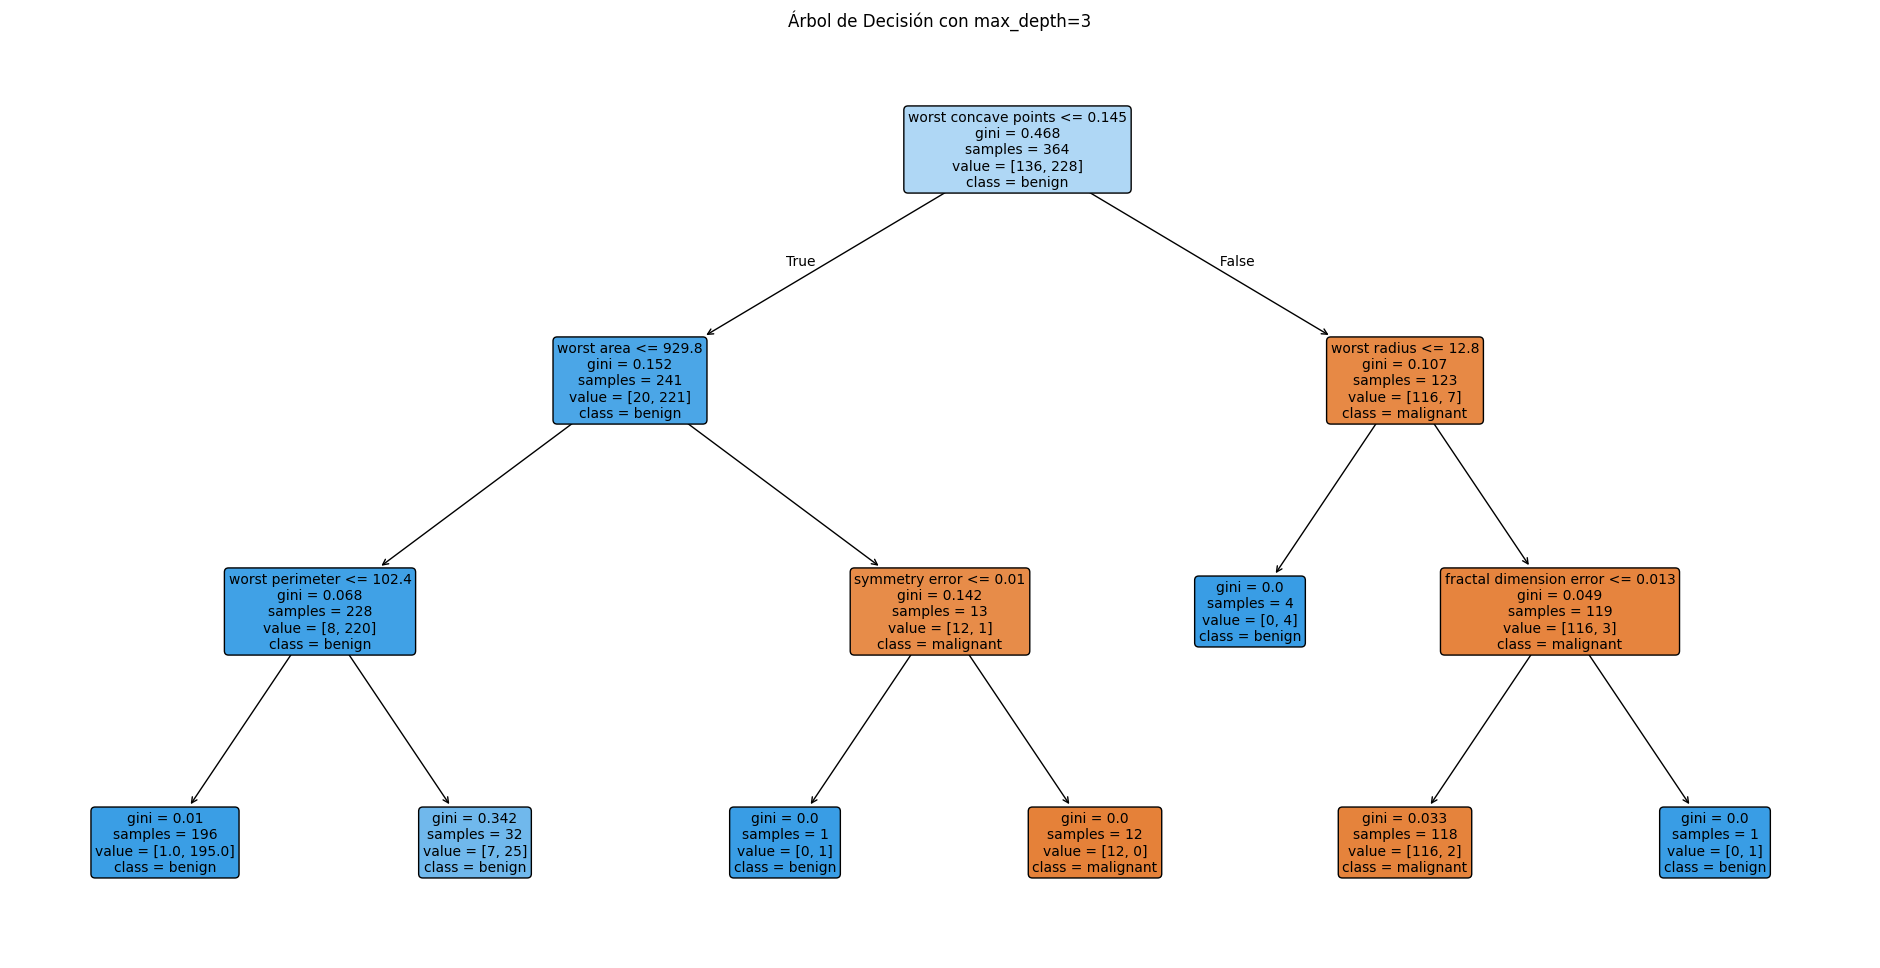

In [7]:
# ---------------------------------------------------------
# Visualización del Árbol de Decisión
# ---------------------------------------------------------

plt.figure(figsize=(24, 12))

plot_tree(
    arbol_simple,
    feature_names=X.columns,
    class_names=datos.target_names,
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Árbol de Decisión con max_depth=3")
plt.show()

## Cómo leer el árbol visualizado

El gráfico anterior muestra la estructura del árbol entrenado.

Cada recuadro representa un **nodo** del árbol. En cada nodo podemos leer información importante:

- La primera línea muestra la **condición** que evalúa el árbol.
- `gini` indica el nivel de impureza del nodo. Un valor cercano a 0 significa que el nodo contiene casos casi todos de una misma clase.
- `samples` indica cuántos registros llegaron a ese nodo.
- `value` muestra cuántos casos de cada clase llegaron a ese nodo. En este gráfico, el primer número corresponde a `malignant` y el segundo a `benign`, siguiendo el orden de `datos.target_names`.
- `class` indica cuál es la clase mayoritaria en ese nodo y, por lo tanto, la predicción que haría el modelo allí.

El recorrido comienza en el nodo superior, llamado **nodo raíz**. Desde allí, el árbol evalúa una condición. Si la condición se cumple, sigue por la rama izquierda; si no se cumple, sigue por la rama derecha.

En este caso, la primera pregunta que hace el árbol es sobre la variable `worst radius`. A partir de esa primera división, el modelo sigue realizando nuevas preguntas hasta llegar a una hoja final, donde se obtiene la predicción.

## Interpretación de una ruta de decisión

Una forma de entender un Árbol de Decisión es seguir una ruta completa desde el nodo raíz hasta una hoja.

El procedimiento siempre es el mismo:

1. El árbol comienza en el nodo raíz y evalúa una condición sobre una variable.
2. Si la condición se cumple, avanza por la rama izquierda; si no, por la derecha.
3. En el siguiente nodo evalúa una nueva condición.
4. El proceso continúa hasta llegar a una hoja.
5. La hoja contiene la clase que el árbol utilizará como predicción.

Los nombres de las variables y los valores de los umbrales pueden verse directamente en el árbol generado en la celda anterior.

Una ruta podría leerse conceptualmente así:

> Si una determinada medición está por debajo de cierto umbral, y luego otra medición también satisface una segunda condición, el registro continúa por esa secuencia de ramas hasta llegar a una hoja donde predomina una de las clases.

Esta lectura paso a paso es una de las razones por las que los Árboles de Decisión son modelos fáciles de interpretar y comunicar.

## Evaluación inicial del Árbol de Decisión

Como todavía estamos explorando el comportamiento del modelo, vamos a evaluarlo sobre el **conjunto de validación**, no sobre el conjunto de prueba.

Usaremos métricas conocidas:

- `accuracy`, para medir la proporción general de aciertos;
- `precision`, `recall` y `f1-score`, mediante `classification_report`;
- matriz de confusión, para observar aciertos y errores por clase.

El conjunto de prueba seguirá reservado hasta el final.

Accuracy del Árbol de Decisión simple (validación):
0.945054945054945

Reporte de clasificación:
              precision    recall  f1-score   support

   malignant       0.94      0.91      0.93        34
      benign       0.95      0.96      0.96        57

    accuracy                           0.95        91
   macro avg       0.94      0.94      0.94        91
weighted avg       0.94      0.95      0.94        91



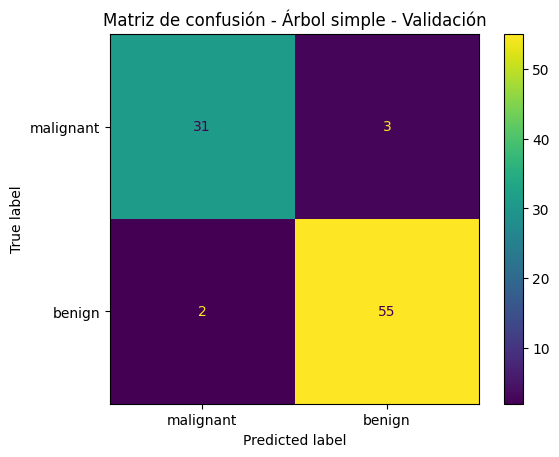

In [8]:
# ---------------------------------------------------------
# Evaluación del Árbol de Decisión sobre validación
# ---------------------------------------------------------

y_pred_arbol_simple = arbol_simple.predict(X_val)

accuracy_arbol_simple = accuracy_score(
    y_val,
    y_pred_arbol_simple
)

print("Accuracy del Árbol de Decisión simple (validación):")
print(accuracy_arbol_simple)

print("\nReporte de clasificación:")
print(classification_report(
    y_val,
    y_pred_arbol_simple,
    target_names=datos.target_names
))

matriz_arbol_simple = confusion_matrix(
    y_val,
    y_pred_arbol_simple
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz_arbol_simple,
    display_labels=datos.target_names
)

disp.plot()
plt.title("Matriz de confusión - Árbol simple - Validación")
plt.show()

## Interpretación de los resultados del árbol simple

El Árbol de Decisión con `max_depth=3` obtuvo sobre validación un `accuracy` aproximado de **0.945**.

El reporte muestra además un comportamiento bastante equilibrado entre las dos clases:

- para `malignant`, el `recall` fue aproximadamente **0.91**;
- para `benign`, el `recall` fue aproximadamente **0.96**.

Esto indica que, aun con una profundidad limitada, el árbol logró capturar patrones útiles.

Todavía no podemos concluir que esta profundidad sea la mejor. Un árbol más profundo podría adaptarse mejor al entrenamiento, pero también podría comenzar a aprender detalles demasiado específicos.

Por eso, en la próxima sección compararemos este árbol con otro sin límite explícito de profundidad, usando validación para analizar qué ocurre fuera de los datos de entrenamiento.

## Profundidad del árbol y sobreajuste

La profundidad de un árbol indica cuántos niveles de preguntas puede hacer antes de llegar a una hoja.

Un árbol con poca profundidad suele ser más simple y más fácil de interpretar, pero puede quedarse corto si el problema requiere decisiones más complejas.

En cambio, un árbol muy profundo puede ajustarse demasiado a los datos de entrenamiento. En ese caso, el modelo puede aprender detalles muy específicos del conjunto de entrenamiento, pero no necesariamente patrones generales. A este problema lo llamamos **sobreajuste** u **overfitting**.

Para analizarlo, vamos a comparar:

- un árbol limitado con `max_depth=3`;
- un árbol sin límite explícito de profundidad.

Compararemos su rendimiento sobre **entrenamiento y validación**. El conjunto de prueba continúa reservado para el final.

In [9]:
# ---------------------------------------------------------
# Comparación entre árbol limitado y árbol sin límite
# ---------------------------------------------------------

arbol_sin_limite = DecisionTreeClassifier(
    random_state=42
)

arbol_sin_limite.fit(
    X_train_modelo,
    y_train_modelo
)

# Predicciones sobre entrenamiento
y_pred_train_simple = arbol_simple.predict(X_train_modelo)
y_pred_train_sin_limite = arbol_sin_limite.predict(X_train_modelo)

# Predicciones sobre validación
y_pred_val_simple = arbol_simple.predict(X_val)
y_pred_val_sin_limite = arbol_sin_limite.predict(X_val)

resultados_arboles = pd.DataFrame({
    "modelo": [
        "Árbol max_depth=3",
        "Árbol sin límite"
    ],
    "accuracy_train": [
        accuracy_score(y_train_modelo, y_pred_train_simple),
        accuracy_score(y_train_modelo, y_pred_train_sin_limite)
    ],
    "accuracy_validacion": [
        accuracy_score(y_val, y_pred_val_simple),
        accuracy_score(y_val, y_pred_val_sin_limite)
    ]
})

resultados_arboles

,modelo,accuracy_train,accuracy_validacion
0,Árbol max_depth=3,0.972527,0.945055
1,Árbol sin límite,1.000000,0.945055


## Interpretación: señales de sobreajuste

La comparación muestra un resultado interesante.

El árbol con `max_depth=3` obtuvo aproximadamente:

- `accuracy_train = 0.973`;
- `accuracy_validacion = 0.945`.

El árbol sin límite, en cambio, alcanzó:

- `accuracy_train = 1.000`;
- `accuracy_validacion = 0.945`.

Es decir, el árbol sin límite logró clasificar perfectamente los datos de entrenamiento, pero **no mejoró el rendimiento sobre validación**.

Esto es una señal muy útil para comprender el sobreajuste: el árbol más complejo aprendió con mayor detalle los datos que ya conocía, pero ese aumento de complejidad no produjo una mejora al enfrentarse a datos nuevos.

En este caso concreto, ambos árboles empatan en validación. Por eso no podemos decir que el árbol sin límite generaliza peor, pero sí podemos afirmar que construye una solución más compleja sin obtener una ventaja observable sobre validación.

La idea importante es que un mejor rendimiento en entrenamiento no implica necesariamente un mejor modelo.

## Complejidad de los árboles

Para entender mejor la diferencia entre los dos modelos, podemos observar dos datos internos de cada árbol:

- La **profundidad**, que indica cuántos niveles de decisiones tiene.
- La **cantidad de hojas**, que indica cuántos resultados finales posibles generó el árbol.

Un árbol más profundo y con más hojas suele ser más complejo. Esa complejidad puede ayudar a capturar más detalles, pero también puede aumentar el riesgo de sobreajuste.

In [10]:
# ---------------------------------------------------------
# Comparación de complejidad entre árboles
# ---------------------------------------------------------

complejidad_arboles = pd.DataFrame({
    "modelo": [
        "Árbol max_depth=3",
        "Árbol sin límite"
    ],
    "profundidad": [
        arbol_simple.get_depth(),
        arbol_sin_limite.get_depth()
    ],
    "cantidad_hojas": [
        arbol_simple.get_n_leaves(),
        arbol_sin_limite.get_n_leaves()
    ]
})

complejidad_arboles

,modelo,profundidad,cantidad_hojas
0,Árbol max_depth=3,3,7
1,Árbol sin límite,6,16


## Interpretación de la complejidad

La tabla muestra que el árbol limitado tiene una profundidad de **3** y genera **7 hojas**. Es un modelo más simple, con menos decisiones posibles y, por lo tanto, más fácil de visualizar e interpretar.

El árbol sin límite, en cambio, alcanza una profundidad de **7** y genera **19 hojas**. Esto significa que realizó más divisiones y construyó reglas más específicas.

Este aumento de complejidad explica por qué logró un rendimiento perfecto sobre los datos de entrenamiento, pero no necesariamente mejoró sobre los datos de prueba. El modelo más complejo tuvo más capacidad para memorizar detalles del conjunto de entrenamiento, pero eso no se tradujo en una mejor generalización.


Antes de avanzar hacia Random Forest, vamos a visualizar el árbol sin límite. No lo haremos para interpretar cada nodo en detalle, sino para observar cómo se ve un árbol más complejo.

## Visualización del árbol sin límite de profundidad

Ahora vamos a representar gráficamente el árbol entrenado sin límite explícito de profundidad.

El objetivo no es analizar cada nodo en detalle, sino observar cómo aumenta la complejidad del modelo cuando se le permite crecer libremente.

Comparado con el árbol anterior, este nuevo gráfico debería mostrar una estructura más extensa, con más ramas y más hojas. Esto ayuda a entender por qué un árbol demasiado profundo puede volverse más difícil de interpretar y más propenso al sobreajuste.

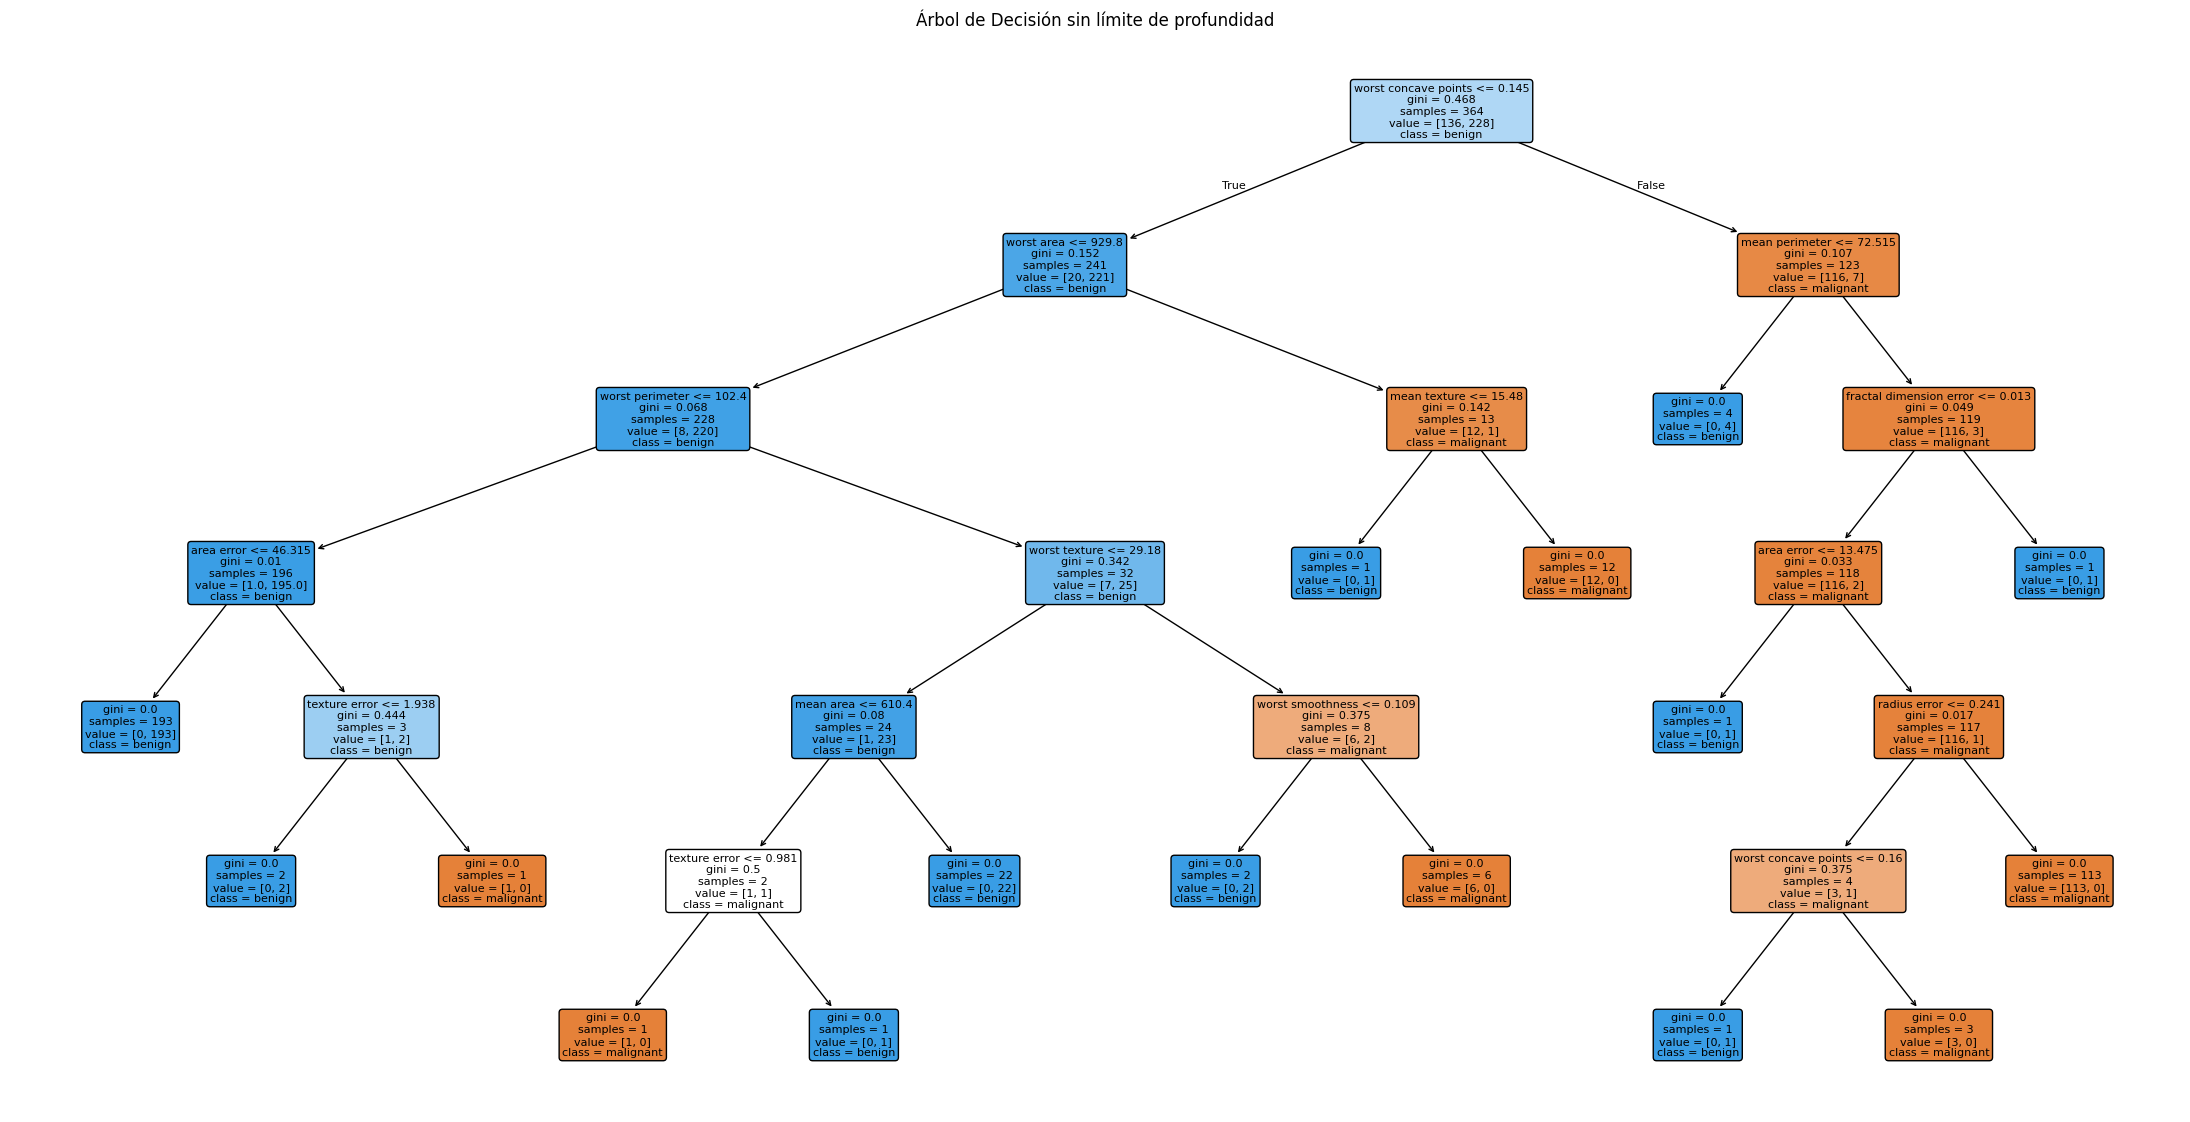

In [11]:
# ---------------------------------------------------------
# Visualización del árbol sin límite de profundidad
# ---------------------------------------------------------

plt.figure(figsize=(28, 14))

plot_tree(
    arbol_sin_limite,
    feature_names=X.columns,
    class_names=datos.target_names,
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Árbol de Decisión sin límite de profundidad")
plt.show()

## Comparación visual entre ambos árboles

El árbol sin límite de profundidad resulta mucho más difícil de leer que el árbol limitado.

Aunque en este caso todavía no es un árbol enorme, ya se observa una estructura más compleja, con más ramas, más divisiones y más hojas. Esto permite ver de manera visual lo que antes observamos en las tablas: el modelo sin límite construyó más reglas de decisión.

Esta mayor complejidad puede parecer una ventaja, porque el modelo tiene más capacidad para adaptarse a los datos. Sin embargo, también puede convertirse en un problema: cuanto más específico se vuelve el árbol, mayor es el riesgo de que aprenda detalles particulares del conjunto de entrenamiento y no patrones generales.

Por eso, en muchos casos no buscamos el árbol más profundo posible, sino un equilibrio entre rendimiento, interpretabilidad y capacidad de generalización.

Esta observación nos lleva a una pregunta importante:

**¿Podemos aprovechar la lógica de los árboles de decisión, pero reduciendo su inestabilidad y su tendencia al sobreajuste?**

La respuesta a esa pregunta nos permite introducir el siguiente modelo: **Random Forest**.

# Random Forest

Hasta ahora trabajamos con Árboles de Decisión individuales. Vimos que son modelos claros, visuales e interpretables, pero también que un árbol puede volverse inestable o sobreajustarse si crece demasiado.

Random Forest parte de una idea sencilla:

**en lugar de confiar en un solo árbol, podemos entrenar muchos árboles diferentes y combinar sus predicciones.**

Conceptualmente suele explicarse como una “votación” entre árboles. Esa imagen es útil para entender la idea general, pero la implementación de `RandomForestClassifier` en Scikit-learn hace algo un poco más preciso: **cada árbol aporta probabilidades para las distintas clases, el bosque promedia esas probabilidades y finalmente elige la clase con mayor probabilidad promedio**.

Por ejemplo, imaginemos tres árboles y dos clases:

```text
Árbol 1 → clase A: 0.90 | clase B: 0.10
Árbol 2 → clase A: 0.60 | clase B: 0.40
Árbol 3 → clase A: 0.20 | clase B: 0.80
```

El bosque calcula el promedio:

```text
clase A → (0.90 + 0.60 + 0.20) / 3 ≈ 0.57
clase B → (0.10 + 0.40 + 0.80) / 3 ≈ 0.43
```

y predice **clase A**.

Por eso, hablar de “votación” sigue siendo una buena metáfora, pero debemos recordar que internamente Scikit-learn combina probabilidades, no solamente etiquetas finales.

## ¿Cómo logra diversidad un Random Forest?

Un Random Forest no entrena muchos árboles idénticos. Para que el conjunto sea útil, necesita que cada árbol tenga cierta diversidad.

Esa diversidad se logra principalmente de dos maneras:

**1. Muestreo con reemplazo**

Cada árbol se construye a partir de una muestra aleatoria del conjunto de entrenamiento. Esta muestra se toma **con reemplazo**, lo que significa que algunos registros pueden aparecer más de una vez y otros pueden quedar afuera.

Este procedimiento se conoce como **bootstrap**.

**2. Selección aleatoria de variables**

En cada división del árbol, el modelo no evalúa necesariamente todas las variables disponibles. Considera solamente un subconjunto aleatorio de ellas.

Esto ayuda a evitar que todos los árboles construyan exactamente las mismas reglas.

Cuando llega el momento de predecir, cada árbol aporta probabilidades para las distintas clases. Random Forest promedia esas probabilidades y selecciona la clase con el promedio más alto.

La diversidad entre árboles es importante porque permite que errores individuales puedan compensarse al combinar el conjunto.

## Entrenamiento de un Random Forest

Ahora vamos a entrenar un modelo usando `RandomForestClassifier`.

Para comenzar, usaremos una configuración simple:

- `n_estimators=100`: el bosque estará formado por 100 árboles.
- `random_state=42`: fijamos la semilla para que los resultados sean reproducibles.

Como todavía estamos comparando modelos, este bosque se entrenará con `X_train_modelo` y se evaluará sobre validación.

In [12]:
# ---------------------------------------------------------
# Entrenamiento de un Random Forest
# ---------------------------------------------------------

bosque = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

bosque.fit(
    X_train_modelo,
    y_train_modelo
)

print("Modelo Random Forest entrenado correctamente.")

Modelo Random Forest entrenado correctamente.


## Evaluación del Random Forest

Vamos a evaluar este Random Forest sobre el **conjunto de validación**.

Usaremos las mismas métricas que aplicamos al Árbol de Decisión:

- `accuracy`;
- `precision`, `recall` y `f1-score`;
- matriz de confusión.

Esto permite comparar modelos sin utilizar todavía el conjunto de prueba.

Accuracy del Random Forest (validación):
0.9560439560439561

Reporte de clasificación:
              precision    recall  f1-score   support

   malignant       0.94      0.94      0.94        34
      benign       0.96      0.96      0.96        57

    accuracy                           0.96        91
   macro avg       0.95      0.95      0.95        91
weighted avg       0.96      0.96      0.96        91



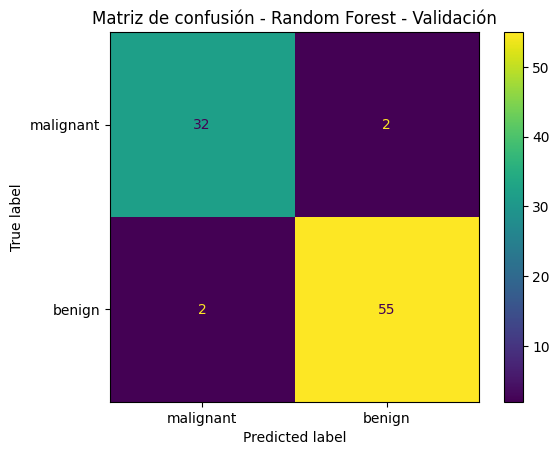

In [13]:
# ---------------------------------------------------------
# Evaluación del Random Forest sobre validación
# ---------------------------------------------------------

y_pred_bosque = bosque.predict(X_val)

accuracy_bosque = accuracy_score(
    y_val,
    y_pred_bosque
)

print("Accuracy del Random Forest (validación):")
print(accuracy_bosque)

print("\nReporte de clasificación:")
print(classification_report(
    y_val,
    y_pred_bosque,
    target_names=datos.target_names
))

matriz_bosque = confusion_matrix(
    y_val,
    y_pred_bosque
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz_bosque,
    display_labels=datos.target_names
)

disp.plot()
plt.title("Matriz de confusión - Random Forest - Validación")
plt.show()

## Interpretación de los resultados del Random Forest

El Random Forest obtuvo sobre validación un `accuracy` aproximado de **0.956**.

El rendimiento fue alto para ambas clases:

- `precision`, `recall` y `f1-score` quedaron alrededor de **0.94–0.96**;
- el comportamiento fue bastante equilibrado entre `malignant` y `benign`.

En esta ejecución, el bosque supera ligeramente a los dos árboles individuales, que habían obtenido aproximadamente **0.945** sobre validación.

La diferencia no es enorme, pero sirve para observar que combinar muchos árboles puede producir una mejora respecto de depender de una única estructura de decisión.

Todavía no debemos interpretar este resultado como rendimiento final: el conjunto de prueba continúa reservado.

## Algunos árboles dentro del bosque

Aunque el Random Forest se comporta como un único modelo, en realidad está formado por muchos árboles de decisión.

Cada uno de esos árboles fue entrenado con cierta variación en los datos y en las variables consideradas en cada división. Por eso, los árboles del bosque **no son idénticos entre sí**.

A continuación vamos a visualizar algunos árboles del bosque. No buscamos analizarlos en detalle, sino observar que presentan estructuras diferentes.

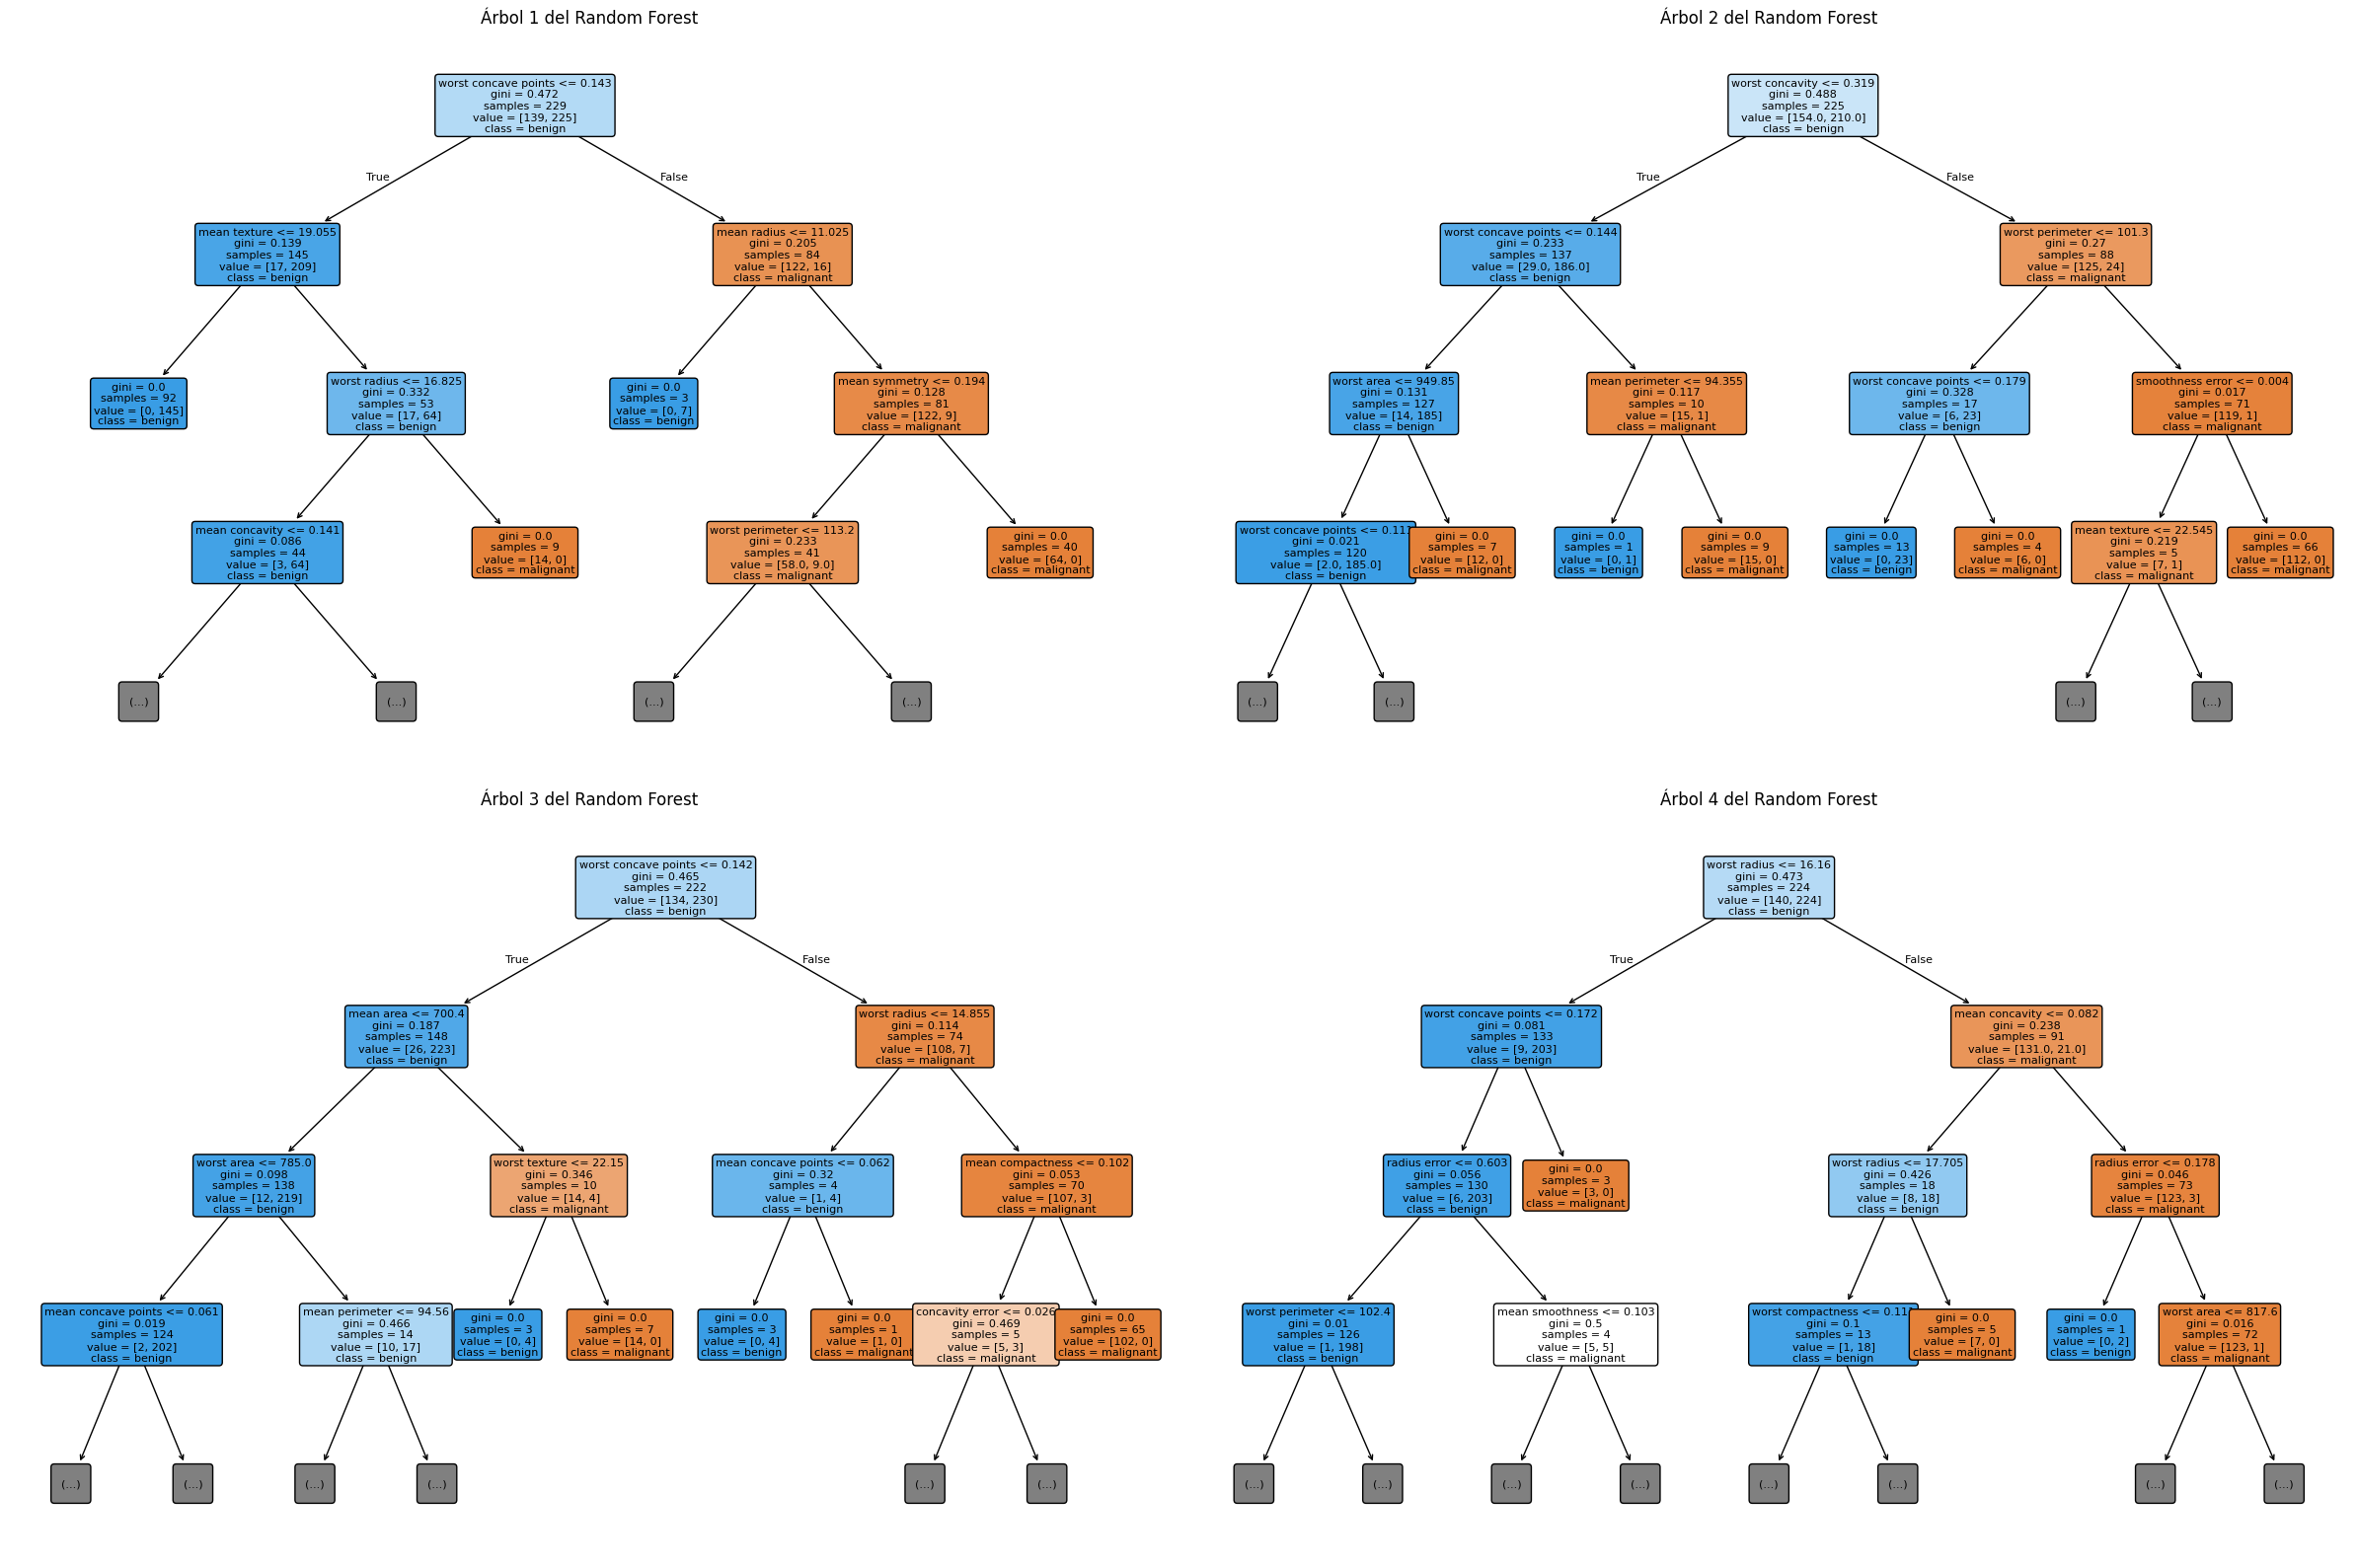

In [14]:
# ---------------------------------------------------------
# Visualización de algunos árboles del Random Forest
# ---------------------------------------------------------

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(24, 16))

for i, ax in enumerate(axes.flatten()):
    plot_tree(
        bosque.estimators_[i],
        feature_names=X.columns,
        class_names=datos.target_names,
        filled=True,
        rounded=True,
        max_depth=3,
        fontsize=8,
        ax=ax
    )
    ax.set_title(f"Árbol {i+1} del Random Forest")

plt.tight_layout()
plt.show()

## Interpretación: árboles diferentes, decisión colectiva

Los árboles que vimos forman parte del mismo Random Forest, pero no son idénticos entre sí.

Cada uno se construye con variaciones en los datos disponibles y en las variables consideradas para realizar sus divisiones. Por eso, sus preguntas, ramas y hojas pueden ser diferentes.

Esta diversidad es importante: si todos los árboles fueran iguales, combinarlos aportaría muy poco.

Podemos pensar intuitivamente que cada árbol “vota”, pero en `RandomForestClassifier` la combinación final se realiza de una manera más precisa:

- cada árbol calcula una probabilidad para cada clase;
- para cada clase, Random Forest promedia las probabilidades aportadas por todos los árboles;
- la clase con la mayor probabilidad promedio se convierte en la predicción final.

En muchas situaciones esto coincide con la clase que recibiría más votos si contáramos únicamente las predicciones finales de los árboles, pero no son exactamente el mismo procedimiento.

Por eso, en las próximas celdas observaremos tanto las predicciones individuales de los árboles como las probabilidades que utiliza realmente el bosque.

## ¿Cómo combinan sus respuestas los árboles del bosque?

Vamos a elegir un caso del conjunto de validación y mirar el proceso con mayor detalle.

Para ese caso observaremos dos cosas:

1. **La predicción individual de cada árbol**, que podemos contar como si fueran votos. Esto resulta intuitivo para entender el grado de acuerdo entre los árboles.
2. **Las probabilidades aportadas por cada árbol**. Estas son las que realmente combina Scikit-learn: para cada clase calcula el promedio de las probabilidades y elige la clase con el promedio más alto.

Así podremos distinguir la metáfora de la “votación” del mecanismo exacto utilizado por `RandomForestClassifier`.

In [15]:
# ---------------------------------------------------------
# Predicciones y probabilidades para un caso particular
# ---------------------------------------------------------

indice_caso = 0

caso_df = X_val.iloc[[indice_caso]]
caso_array = caso_df.to_numpy()

# ---------------------------------------------------------
# 1. Predicciones individuales: "votos" de los árboles
# ---------------------------------------------------------

votos = []

for arbol in bosque.estimators_:
    prediccion = int(arbol.predict(caso_array)[0])
    votos.append(prediccion)

votos = pd.Series(votos)

conteo_votos = (
    votos.value_counts()
    .sort_index()
    .reindex([0, 1], fill_value=0)
)

# ---------------------------------------------------------
# 2. Probabilidades aportadas por cada árbol
# ---------------------------------------------------------

probabilidades_arboles = []

for arbol in bosque.estimators_:
    probabilidades = arbol.predict_proba(caso_array)[0]
    probabilidades_arboles.append(probabilidades)

probabilidades_arboles = np.array(probabilidades_arboles)

# Promedio manual de las probabilidades de los árboles
promedio_probabilidades = probabilidades_arboles.mean(axis=0)

# Probabilidades calculadas directamente por el bosque
probabilidades_bosque = bosque.predict_proba(caso_df)[0]

clase_real = int(y_val.iloc[indice_caso])
prediccion_bosque = int(bosque.predict(caso_df)[0])

print("Clase real:", datos.target_names[clase_real])
print("Predicción final:", datos.target_names[prediccion_bosque])

print("\nPredicciones individuales de los árboles:")
for clase, cantidad in conteo_votos.items():
    print(f"{datos.target_names[int(clase)]}: {cantidad}")

print("\nPromedio manual de probabilidades:")
for i, prob in enumerate(promedio_probabilidades):
    print(f"{datos.target_names[i]}: {prob:.4f}")

print("\nProbabilidades devueltas por Random Forest:")
for i, prob in enumerate(probabilidades_bosque):
    print(f"{datos.target_names[i]}: {prob:.4f}")

Clase real: benign
Predicción final: benign

Predicciones individuales de los árboles:
malignant: 1
benign: 99

Promedio manual de probabilidades:
malignant: 0.0100
benign: 0.9900

Probabilidades devueltas por Random Forest:
malignant: 0.0100
benign: 0.9900


## Búsqueda de un caso con una decisión más dividida

En el primer ejemplo, 99 de los 100 árboles predijeron `benign`, y las probabilidades finales fueron aproximadamente `0.01` para `malignant` y `0.99` para `benign`.

Para observar un caso menos definido, vamos a buscar dentro del conjunto de validación aquel donde las probabilidades finales de ambas clases estén lo más próximas posible.

Una probabilidad cercana a `0.50 / 0.50` indicaría que el soporte interno del bosque está muy repartido entre ambas clases.

Esto no debe interpretarse como una medida perfecta de “seguridad” o confianza clínica. Simplemente nos permite estudiar un caso donde la decisión interna del modelo resulta menos marcada.

In [16]:
# ---------------------------------------------------------
# Búsqueda del caso con probabilidades más parejas
# ---------------------------------------------------------

resultados_votacion = []

for indice_caso in range(len(X_val)):

    caso_df = X_val.iloc[[indice_caso]]
    caso_array = caso_df.to_numpy()

    # Predicciones individuales de los árboles
    votos = []

    for arbol in bosque.estimators_:
        votos.append(
            int(arbol.predict(caso_array)[0])
        )

    votos = pd.Series(votos)
    conteo_votos = votos.value_counts().reindex(
        [0, 1],
        fill_value=0
    )

    # Probabilidades finales del Random Forest
    probabilidades = bosque.predict_proba(caso_df)[0]

    diferencia_prob = abs(
        probabilidades[0] - probabilidades[1]
    )

    resultados_votacion.append({
        "indice_caso": indice_caso,
        "votos_malignant": conteo_votos[0],
        "votos_benign": conteo_votos[1],
        "prob_malignant": probabilidades[0],
        "prob_benign": probabilidades[1],
        "diferencia_prob": diferencia_prob,
        "clase_real": int(y_val.iloc[indice_caso]),
        "prediccion_bosque": int(
            bosque.predict(caso_df)[0]
        )
    })

df_votacion = pd.DataFrame(resultados_votacion)

df_votacion_ordenado = df_votacion.sort_values(
    "diferencia_prob"
)

display(df_votacion_ordenado.head(10))

,indice_caso,votos_malignant,votos_benign,prob_malignant,prob_benign,diferencia_prob,clase_real,prediccion_bosque
6,6,60,40,0.60,0.40,0.20,0,0
49,49,36,64,0.36,0.64,0.28,0,1
32,32,33,67,0.33,0.67,0.34,1,1
63,63,69,31,0.69,0.31,0.38,0,0
87,87,72,28,0.72,0.28,0.44,1,0
90,90,74,26,0.74,0.26,0.48,0,0
51,51,21,79,0.21,0.79,0.58,1,1
34,34,17,83,0.17,0.83,0.66,1,1
69,69,84,16,0.84,0.16,0.68,0,0
83,83,85,15,0.85,0.15,0.70,1,0


## Análisis de un caso con probabilidades divididas

La tabla anterior ordenó los casos según qué tan próximas están las probabilidades de las dos clases.

En lugar de fijar manualmente un índice, vamos a tomar automáticamente el primer caso de esa tabla: el que presenta la menor diferencia entre las probabilidades finales.

Así el ejemplo seguirá siendo válido aunque cambien los datos, la semilla o algún hiperparámetro del modelo.

In [17]:
# ---------------------------------------------------------
# Análisis detallado del caso más dividido
# ---------------------------------------------------------

indice_caso = int(
    df_votacion_ordenado.iloc[0]["indice_caso"]
)

caso_df = X_val.iloc[[indice_caso]]
caso_array = caso_df.to_numpy()

# Predicciones individuales de los árboles
votos = []

for arbol in bosque.estimators_:
    votos.append(
        int(arbol.predict(caso_array)[0])
    )

votos = pd.Series(votos)

conteo_votos = (
    votos.value_counts()
    .sort_index()
    .reindex([0, 1], fill_value=0)
)

# Probabilidades individuales de cada árbol
probabilidades_arboles = np.array([
    arbol.predict_proba(caso_array)[0]
    for arbol in bosque.estimators_
])

promedio_probabilidades = probabilidades_arboles.mean(
    axis=0
)

probabilidades_bosque = bosque.predict_proba(
    caso_df
)[0]

clase_real = int(y_val.iloc[indice_caso])
prediccion_bosque = int(
    bosque.predict(caso_df)[0]
)

print("Caso analizado:", indice_caso)
print("Clase real:", datos.target_names[clase_real])
print("Predicción final:", datos.target_names[prediccion_bosque])

print("\nPredicciones individuales de los árboles:")
for clase, cantidad in conteo_votos.items():
    print(f"{datos.target_names[int(clase)]}: {cantidad}")

print("\nPromedio de probabilidades de los árboles:")
for i, prob in enumerate(promedio_probabilidades):
    print(f"{datos.target_names[i]}: {prob:.4f}")

print("\nProbabilidades finales del Random Forest:")
for i, prob in enumerate(probabilidades_bosque):
    print(f"{datos.target_names[i]}: {prob:.4f}")

Caso analizado: 6
Clase real: malignant
Predicción final: malignant

Predicciones individuales de los árboles:
malignant: 60
benign: 40

Promedio de probabilidades de los árboles:
malignant: 0.6000
benign: 0.4000

Probabilidades finales del Random Forest:
malignant: 0.6000
benign: 0.4000


## Interpretación del caso analizado

El caso seleccionado automáticamente fue el `indice_caso = 6`.

Para ese registro:

- 60 árboles predijeron `malignant`;
- 40 árboles predijeron `benign`;
- la probabilidad final fue `0.60` para `malignant` y `0.40` para `benign`;
- la clase real también era `malignant`.

En este ejemplo particular, el conteo de predicciones individuales y las probabilidades finales coinciden exactamente.

Eso ocurre porque, para este caso, las probabilidades aportadas por los árboles terminan produciendo el mismo resultado que contar sus predicciones finales. Sin embargo, **no debemos asumir que siempre será así**.

Conceptualmente:

- contar las predicciones individuales nos da una idea intuitiva de “votos”;
- `RandomForestClassifier` obtiene su predicción promediando las probabilidades de clase aportadas por todos los árboles.

Por eso, la metáfora de la votación es útil para comprender el modelo, pero el promedio de probabilidades describe con mayor precisión lo que hace Scikit-learn.

## Comparación entre Árboles de Decisión y Random Forest

Ahora vamos a comparar los tres modelos que entrenamos hasta el momento:

- Árbol de Decisión con `max_depth=3`;
- Árbol de Decisión sin límite explícito;
- Random Forest con 100 árboles.

Para cada modelo calcularemos el `accuracy` sobre entrenamiento y validación.

Esta comparación forma parte del proceso de análisis y selección. Por eso todavía no utilizamos el conjunto de prueba.

In [18]:
# ---------------------------------------------------------
# Comparación general de modelos
# ---------------------------------------------------------

# Predicciones del Random Forest
y_pred_train_bosque = bosque.predict(X_train_modelo)
y_pred_val_bosque = bosque.predict(X_val)

comparacion_modelos = pd.DataFrame({
    "modelo": [
        "Árbol max_depth=3",
        "Árbol sin límite",
        "Random Forest"
    ],
    "accuracy_train": [
        accuracy_score(y_train_modelo, y_pred_train_simple),
        accuracy_score(y_train_modelo, y_pred_train_sin_limite),
        accuracy_score(y_train_modelo, y_pred_train_bosque)
    ],
    "accuracy_validacion": [
        accuracy_score(y_val, y_pred_val_simple),
        accuracy_score(y_val, y_pred_val_sin_limite),
        accuracy_score(y_val, y_pred_val_bosque)
    ]
})

comparacion_modelos

,modelo,accuracy_train,accuracy_validacion
0,Árbol max_depth=3,0.972527,0.945055
1,Árbol sin límite,1.000000,0.945055
2,Random Forest,1.000000,0.956044


## Visualización comparativa del rendimiento de los modelos

La tabla anterior permite comparar los valores de `accuracy` en entrenamiento y validación.

El gráfico siguiente ayuda a observar:

- qué modelos mantienen mejor su rendimiento fuera del entrenamiento;
- qué modelos muestran una diferencia grande entre entrenamiento y validación;
- qué señales pueden interpretarse como posible sobreajuste.

Recordemos que **validación** sirve para comparar alternativas. El conjunto de prueba todavía no participa.

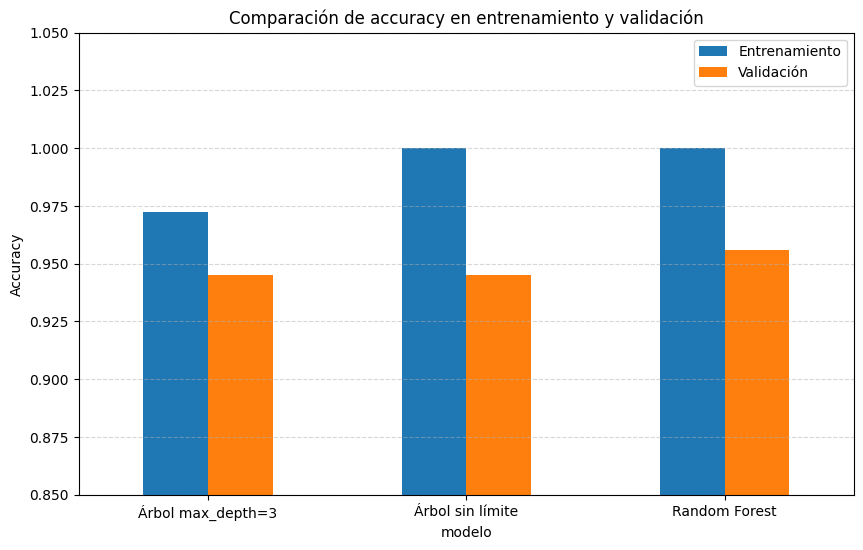

In [19]:
# ---------------------------------------------------------
# Gráfico comparativo de accuracy en train y validación
# ---------------------------------------------------------

comparacion_modelos_graf = comparacion_modelos.set_index(
    "modelo"
)

comparacion_modelos_graf.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title(
    "Comparación de accuracy en entrenamiento y validación"
)
plt.ylabel("Accuracy")
plt.ylim(0.85, 1.05)
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend(["Entrenamiento", "Validación"])
plt.show()

## Interpretación del gráfico comparativo

Los resultados permiten hacer una comparación concreta:

- Árbol con `max_depth=3`: `accuracy_validacion ≈ 0.945`;
- Árbol sin límite: `accuracy_validacion ≈ 0.945`;
- Random Forest: `accuracy_validacion ≈ 0.956`.

El árbol sin límite alcanza `accuracy_train = 1.0`, pero no mejora al árbol limitado sobre validación. Esto muestra que aumentar la complejidad permitió ajustar perfectamente el entrenamiento, aunque sin obtener una ventaja observable fuera de él.

Random Forest también alcanza un ajuste perfecto sobre entrenamiento, pero en esta ejecución logra un resultado ligeramente superior sobre validación.

La diferencia es pequeña, por lo que no conviene sacar conclusiones exageradas a partir de una única partición. Lo importante es observar la relación entre rendimiento de entrenamiento, rendimiento de validación y complejidad del modelo.

## Importancia de las variables en Random Forest

Aunque Random Forest suele ser menos interpretable que un único Árbol de Decisión, podemos obtener información útil sobre las variables que utilizó.

Una herramienta disponible es `feature_importances_`.

Esta medida resume cuánto contribuyó cada variable a reducir la impureza a lo largo de los árboles del bosque. En términos generales, una variable recibe mayor importancia cuando participa en divisiones que producen reducciones importantes de impureza.

Debemos interpretarla con cautela: una importancia alta **no demuestra causalidad**, ni significa necesariamente que esa variable sea la más importante desde el punto de vista científico o médico.

In [20]:
# ---------------------------------------------------------
# Importancia de variables en Random Forest
# ---------------------------------------------------------

# Obtenemos la importancia asignada por el modelo a cada variable
importancias = bosque.feature_importances_

# Creamos un DataFrame para organizar los resultados
df_importancias = pd.DataFrame({
    "variable": X.columns,
    "importancia": importancias
})

# Ordenamos de mayor a menor importancia
df_importancias = df_importancias.sort_values(
    by="importancia",
    ascending=False
)

# Mostramos las 10 variables más importantes
df_importancias.head(10)

,variable,importancia
27,worst concave points,0.156210
23,worst area,0.150473
22,worst perimeter,0.088065
7,mean concave points,0.077163
20,worst radius,0.071733
6,mean concavity,0.063691
2,mean perimeter,0.059460
13,area error,0.050747
0,mean radius,0.047277
26,worst concavity,0.041002


## Gráfico de importancia de variables

La tabla anterior muestra las variables más importantes según el Random Forest.

Para facilitar la interpretación, vamos a representar las 10 variables más relevantes en un gráfico de barras horizontal.

En este gráfico, las variables con barras más largas son aquellas que tuvieron mayor peso en las decisiones del modelo.

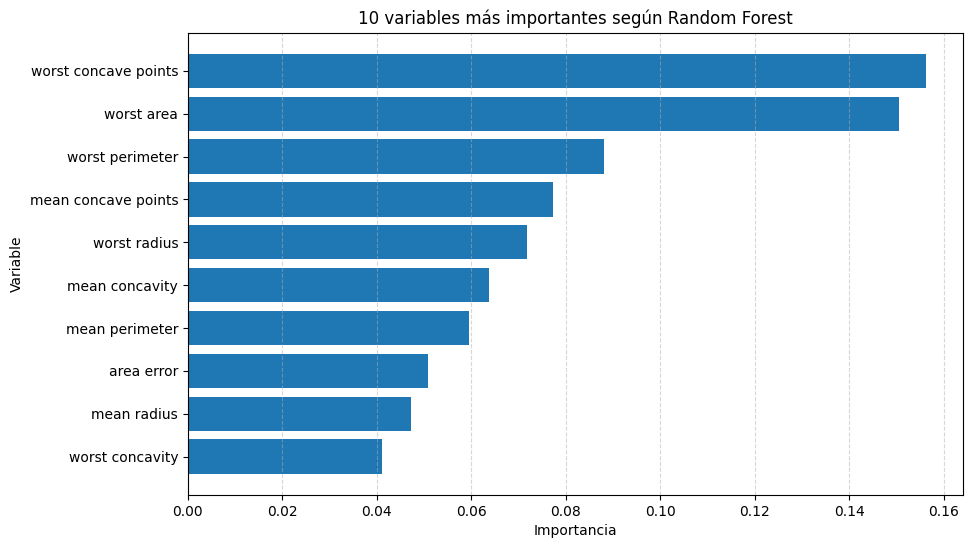

In [21]:
# ---------------------------------------------------------
# Gráfico de importancia de variables
# ---------------------------------------------------------

# Tomamos las 10 variables más importantes
top_importancias = df_importancias.head(10)

# Ordenamos de menor a mayor para que la más importante quede arriba en el gráfico
top_importancias = top_importancias.sort_values("importancia")

plt.figure(figsize=(10, 6))

plt.barh(
    top_importancias["variable"],
    top_importancias["importancia"]
)

plt.title("10 variables más importantes según Random Forest")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.show()

## Interpretación de la importancia de variables

El gráfico muestra que el Random Forest no utilizó todas las variables con el mismo peso.

En esta ejecución, las variables con mayor `feature_importances_` fueron, entre otras:

- `worst concave points`;
- `worst area`;
- `worst perimeter`;
- `mean concave points`;
- `worst radius`.

Esto significa que fueron especialmente útiles para producir divisiones que redujeron la impureza dentro de este bosque.

Es importante no confundir esta medida con causalidad. El modelo no explica por qué ocurre una enfermedad ni demuestra que una variable tenga importancia clínica. Solamente resume cuánto ayudó esa variable a construir las decisiones internas del modelo.

Además, estas importancias dependen de los datos y de la configuración del Random Forest, por lo que pueden cambiar si repetimos el procedimiento en otras condiciones.

## Experimento: cantidad de árboles del bosque

Uno de los hiperparámetros más conocidos de Random Forest es `n_estimators`.

Este parámetro indica cuántos árboles tendrá el bosque.

En general, usar más árboles puede hacer que el modelo sea más estable, aunque también aumenta el costo computacional.

Vamos a probar varias cantidades de árboles y comparar su rendimiento sobre **entrenamiento y validación**.

La validación nos permite realizar este experimento sin utilizar todavía el conjunto de prueba.

In [22]:
# ---------------------------------------------------------
# Comparación de Random Forest con distinta cantidad de árboles
# ---------------------------------------------------------

cantidades_arboles = [
    10, 50, 100, 200
]

resultados_estimadores = []

for cantidad in cantidades_arboles:

    modelo_rf = RandomForestClassifier(
        n_estimators=cantidad,
        random_state=42
    )

    modelo_rf.fit(
        X_train_modelo,
        y_train_modelo
    )

    y_pred_train = modelo_rf.predict(
        X_train_modelo
    )

    y_pred_val = modelo_rf.predict(
        X_val
    )

    resultados_estimadores.append({
        "n_estimators": cantidad,
        "accuracy_train": accuracy_score(
            y_train_modelo,
            y_pred_train
        ),
        "accuracy_validacion": accuracy_score(
            y_val,
            y_pred_val
        )
    })

df_estimadores = pd.DataFrame(
    resultados_estimadores
)

display(df_estimadores)

# Elegimos la menor cantidad de árboles entre las que
# obtuvieron el mejor accuracy de validación.
mejor_accuracy_val = df_estimadores[
    "accuracy_validacion"
].max()

mejor_n_estimators = int(
    df_estimadores[
        df_estimadores["accuracy_validacion"]
        == mejor_accuracy_val
    ]["n_estimators"].min()
)

print(
    "\nCantidad de árboles elegida a partir de validación:",
    mejor_n_estimators
)

,n_estimators,accuracy_train,accuracy_validacion
0,10,1.0,0.956044
1,50,1.0,0.956044
2,100,1.0,0.956044
3,200,1.0,0.956044



Cantidad de árboles elegida a partir de validación: 10


## Visualización del efecto de `n_estimators`

La tabla anterior muestra cómo cambia el rendimiento al modificar la cantidad de árboles.

El eje horizontal del gráfico representará `n_estimators`, mientras que el eje vertical mostrará el `accuracy` obtenido en entrenamiento y validación.

Si varias configuraciones alcanzan el mismo mejor resultado de validación, elegiremos la que utilice menos árboles entre las empatadas. Es un criterio sencillo para este ejemplo didáctico.

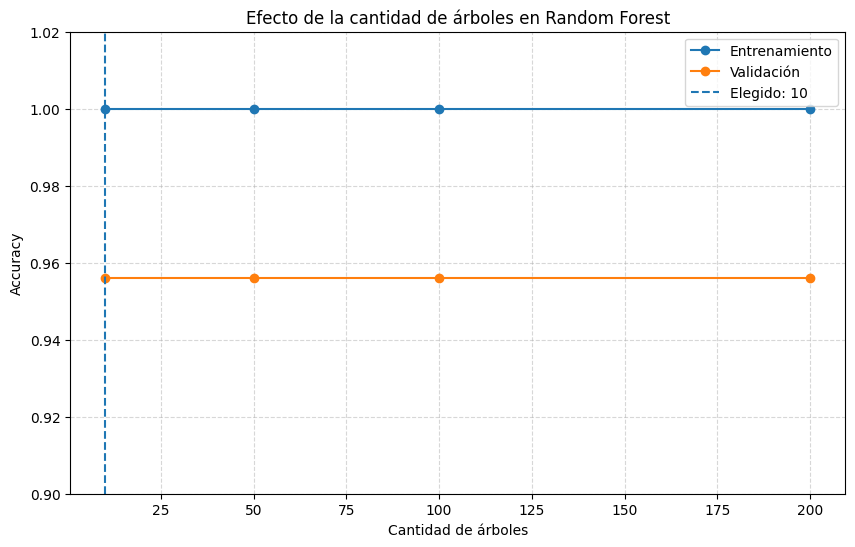

In [23]:
# ---------------------------------------------------------
# Gráfico del efecto de n_estimators
# ---------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    df_estimadores["n_estimators"],
    df_estimadores["accuracy_train"],
    marker="o",
    label="Entrenamiento"
)

plt.plot(
    df_estimadores["n_estimators"],
    df_estimadores["accuracy_validacion"],
    marker="o",
    label="Validación"
)

plt.axvline(
    mejor_n_estimators,
    linestyle="--",
    label=f"Elegido: {mejor_n_estimators}"
)

plt.title(
    "Efecto de la cantidad de árboles en Random Forest"
)
plt.xlabel("Cantidad de árboles")
plt.ylabel("Accuracy")
plt.ylim(0.90, 1.02)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()

plt.show()

## Interpretación del experimento

En esta ejecución ocurrió algo particularmente claro: los cuatro valores probados de `n_estimators` obtuvieron exactamente el mismo `accuracy` sobre validación, aproximadamente **0.956**.

Es decir:

- 10 árboles → `0.956`;
- 50 árboles → `0.956`;
- 100 árboles → `0.956`;
- 200 árboles → `0.956`.

Por lo tanto, con esta métrica y esta partición de los datos, aumentar la cantidad de árboles no produjo ninguna mejora observable.

Como definimos que, en caso de empate, elegiríamos la configuración más simple, el procedimiento seleccionó:

```text
n_estimators = 10
```

Esto no significa que 10 árboles sea siempre la mejor cantidad. Significa solamente que, **entre las alternativas probadas y según este conjunto de validación**, usar más árboles no aportó una ventaja medible en `accuracy`.

Lo importante metodológicamente es que esta decisión se tomó sin consultar el conjunto de prueba.

## Actividad final

A partir de lo trabajado en el cuaderno, realizá las siguientes pruebas:

1. Modificá la profundidad máxima del Árbol de Decisión usando distintos valores de `max_depth`, por ejemplo `2`, `3`, `4`, `5` y `None`.

2. Compará el rendimiento de cada árbol en entrenamiento y **validación**.

3. Modificá algunos hiperparámetros del Random Forest, por ejemplo:
   - `n_estimators`
   - `max_depth`
   - `min_samples_leaf`

4. Observá si el modelo mejora, empeora o se mantiene similar sobre validación.

5. Escribí una breve reflexión:
   - ¿Qué configuración obtuvo mejor rendimiento en validación?
   - ¿Qué modelo resultó más fácil de interpretar?
   - ¿Qué señales de sobreajuste pudiste observar?
   - ¿Qué ventaja concreta aporta Random Forest frente a un único Árbol de Decisión?

> Durante estas pruebas no uses el conjunto de test para elegir hiperparámetros. El test se reserva para una única evaluación final.

## Evaluación final sobre el conjunto de prueba

Hasta ahora utilizamos entrenamiento y validación para comparar modelos y probar configuraciones.

Ahora que ya elegimos una cantidad de árboles a partir de validación, podemos realizar la evaluación final.

Para aprovechar todos los datos disponibles para aprendizaje, entrenaremos un nuevo Random Forest utilizando **todo `X_train`**. Después lo evaluaremos una sola vez sobre `X_test`.

Este paso es importante porque el conjunto de prueba no participó en la elección de `n_estimators`.

n_estimators elegido: 10
Accuracy final sobre test: 0.9385964912280702

Reporte de clasificación final:
              precision    recall  f1-score   support

   malignant       0.91      0.93      0.92        42
      benign       0.96      0.94      0.95        72

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114



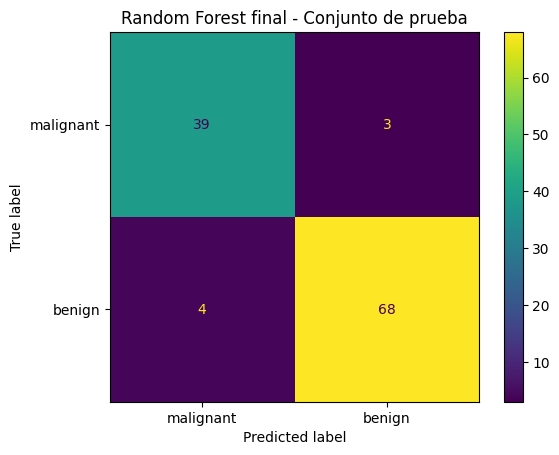

In [24]:
# ---------------------------------------------------------
# Modelo final y evaluación sobre test
# ---------------------------------------------------------

bosque_final = RandomForestClassifier(
    n_estimators=mejor_n_estimators,
    random_state=42
)

# Entrenamos nuevamente utilizando TODO el conjunto de entrenamiento
bosque_final.fit(
    X_train,
    y_train
)

# Recién ahora utilizamos el conjunto de prueba
y_pred_final = bosque_final.predict(
    X_test
)

accuracy_final = accuracy_score(
    y_test,
    y_pred_final
)

print("n_estimators elegido:", mejor_n_estimators)
print("Accuracy final sobre test:", accuracy_final)

print("\nReporte de clasificación final:")
print(classification_report(
    y_test,
    y_pred_final,
    target_names=datos.target_names
))

matriz_final = confusion_matrix(
    y_test,
    y_pred_final
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz_final,
    display_labels=datos.target_names
)

disp.plot()
plt.title("Random Forest final - Conjunto de prueba")
plt.show()

## Interpretación de la evaluación final

El modelo final, entrenado con `n_estimators = 10`, obtuvo sobre el conjunto de prueba:

- `accuracy ≈ 0.939`;
- `precision` de aproximadamente **0.91** para `malignant` y **0.96** para `benign`;
- `recall` de aproximadamente **0.93** para `malignant` y **0.94** para `benign`.

El `accuracy` final quedó algo por debajo del valor observado durante validación (`≈ 0.956`). Esto es completamente posible: validación y prueba contienen registros diferentes y funcionan como muestras distintas del problema.

No debemos volver atrás y cambiar `n_estimators` buscando mejorar ahora el resultado de test. Si lo hiciéramos, el conjunto de prueba dejaría de ser una evaluación independiente y comenzaría a participar en el ajuste del modelo.

Por eso, estas métricas deben interpretarse como la evaluación final del procedimiento que elegimos usando entrenamiento y validación.

# Conclusiones

En este cuaderno trabajamos con dos modelos relacionados: los **Árboles de Decisión** y los **Random Forest**.

Primero vimos que un Árbol de Decisión toma decisiones mediante una secuencia de preguntas y que esa estructura permite seguir una predicción paso a paso. También comprobamos que aumentar la complejidad no garantiza una mejora: el árbol sin límite alcanzó un `accuracy` perfecto sobre entrenamiento, pero obtuvo el mismo rendimiento de validación que el árbol limitado (`≈ 0.945`).

Luego introdujimos **Random Forest**, que combina muchos árboles diferentes. Aunque podemos imaginar intuitivamente este proceso como una votación, vimos que `RandomForestClassifier` combina las probabilidades producidas por sus árboles y selecciona la clase con mayor probabilidad promedio.

El Random Forest con 100 árboles obtuvo aproximadamente `0.956` sobre validación, ligeramente por encima de los árboles individuales. Después probamos distintos valores de `n_estimators` y observamos que `10`, `50`, `100` y `200` árboles alcanzaban exactamente el mismo `accuracy` de validación. Siguiendo el criterio definido para los empates, elegimos la configuración más simple: `n_estimators = 10`.

Finalmente, entrenamos nuevamente el modelo seleccionado usando todo el conjunto de entrenamiento y lo evaluamos una sola vez sobre test. El `accuracy` final fue aproximadamente **0.939**. Que este valor sea algo menor que el de validación no representa un error: son conjuntos distintos y el test se utiliza justamente para obtener una evaluación independiente.

También vimos que estos modelos no necesitan escalado de variables, porque sus decisiones se basan en umbrales y no en distancias, y analizamos `feature_importances_` como una herramienta para estudiar qué variables contribuyeron más a reducir la impureza, sin interpretar esa medida como causalidad.

La idea metodológica central del cuaderno es tan importante como los propios modelos: **entrenamiento para aprender, validación para comparar y decidir, y prueba para evaluar al final**.

----

# Apéndice: ¿qué matemática hay detrás de los Árboles de Decisión?

Durante el cuaderno trabajamos principalmente desde una mirada práctica e interpretativa: entrenamos árboles, los visualizamos, evaluamos sus resultados y luego extendimos la idea hacia Random Forest.

En este apéndice vamos a mirar con un poco más de detalle qué ocurre internamente cuando un árbol decide cómo dividir los datos.

La pregunta central es:

**¿Cómo sabe el árbol cuál es la mejor pregunta para separar los datos?**

Para responder eso, el árbol necesita medir qué tan “mezcladas” están las clases dentro de un nodo. A esa mezcla la llamamos **impureza**.

## Impureza de un nodo

Un nodo es más **puro** cuando contiene casos mayoritariamente de una sola clase.

Por ejemplo, si en un nodo hay 100 casos y los 100 pertenecen a la clase `benign`, ese nodo es completamente puro.

En cambio, si en un nodo hay 50 casos `benign` y 50 casos `malignant`, el nodo está mucho más mezclado. En ese caso, el árbol tiene más incertidumbre sobre qué clase debería predecir.

El objetivo del árbol es encontrar divisiones que generen nodos hijos más puros que el nodo original.

Dicho de otra manera: el árbol busca preguntas que ayuden a separar mejor las clases.

## Índice de Gini

El **índice de Gini** es una medida de impureza. Nos dice qué tan mezcladas están las clases dentro de un nodo.

Su valor mínimo es `0`, y ocurre cuando todos los casos del nodo pertenecen a una sola clase.

La fórmula general es:

$$ Gini = 1 - \sum_{i=1}^{k} p_i^2 $$

donde:

- $k$ es la cantidad de clases.
- $p_i$ es la proporción de casos de la clase $i$ dentro del nodo.

En un problema binario, como el de este cuaderno, hay solo dos clases: `malignant` y `benign`.

## Ejemplo de cálculo del índice de Gini

Supongamos un nodo con 100 casos:

- 80 casos pertenecen a la clase `benign`.
- 20 casos pertenecen a la clase `malignant`.

Entonces las proporciones son:

$$ p_{benign} = 0.80 $$

$$ p_{malignant} = 0.20 $$

Aplicamos la fórmula:

$$ Gini = 1 - (0.80^2 + 0.20^2) $$

$$ Gini = 1 - (0.64 + 0.04) $$

$$ Gini = 1 - 0.68 $$

$$ Gini = 0.32 $$

Este nodo no es perfectamente puro, pero está bastante dominado por una clase. Por eso su impureza no es máxima.

## Entropía

La **entropía** es otra forma de medir la impureza o incertidumbre de un nodo.

Proviene de la teoría de la información y mide cuán desordenada está la distribución de clases.

La fórmula general es:

$$ Entropía = - \sum_{i=1}^{k} p_i \log_2(p_i) $$

donde:

- $k$ es la cantidad de clases.
- $p_i$ es la proporción de casos de la clase $i$ dentro del nodo.
- $\log_2$ es el logaritmo en base 2.

Al igual que Gini, la entropía vale `0` cuando el nodo es completamente puro.

Cuando las clases están muy mezcladas, la entropía aumenta.

## Ejemplo de cálculo de entropía

Usemos el mismo ejemplo anterior:

- 80 casos `benign`.
- 20 casos `malignant`.

Las proporciones son:

$$ p_{benign} = 0.80 $$

$$ p_{malignant} = 0.20 $$

La entropía se calcula así:

$$ Entropía = - (0.80 \log_2(0.80) + 0.20 \log_2(0.20)) $$

El resultado aproximado es:

$$ Entropía \approx 0.722 $$

Si el nodo estuviera dividido en partes iguales, con 50 casos de una clase y 50 de la otra, la entropía sería `1`, que es el máximo posible en un problema binario.

Esto representa una situación de mayor incertidumbre que la distribución 80/20.

## Ganancia de información

Cuando el árbol prueba una posible división, compara la impureza antes y después de dividir.

Una buena división es aquella que reduce la impureza total.

A esa reducción se la conoce como **ganancia de información**.

La idea general es:

$$ Ganancia = Impureza_{antes} - Impureza_{después} $$

Si la ganancia es alta, significa que la división ayudó mucho a separar las clases.

Si la ganancia es baja, significa que la división no aportó demasiado.

Por eso, en cada nodo, el árbol busca la pregunta que produzca la mayor reducción de impureza.

## Impureza ponderada después de una división

Cuando un nodo se divide en dos nodos hijos, no alcanza con mirar la impureza de cada hijo por separado.

También importa cuántos casos quedaron en cada nodo hijo.

Por ejemplo, no tiene el mismo peso un nodo hijo con 200 casos que otro con solo 5 casos.

Por eso, el árbol calcula una impureza ponderada:

$$ Impureza_{división} =
\frac{n_{izq}}{n} \cdot Impureza_{izq}
+
\frac{n_{der}}{n} \cdot Impureza_{der} $$

donde:

- $n$ es la cantidad total de casos del nodo original.
- $n_{izq}$ es la cantidad de casos del nodo izquierdo.
- $n_{der}$ es la cantidad de casos del nodo derecho.
- $Impureza_{izq}$ es la impureza del nodo izquierdo.
- $Impureza_{der}$ es la impureza del nodo derecho.

El árbol compara muchas divisiones posibles y elige aquella que deja la menor impureza ponderada.

## ¿Qué criterio usa Scikit-learn?

En `DecisionTreeClassifier`, el criterio por defecto es `gini`.

Eso significa que, si no indicamos lo contrario, el árbol usa el índice de Gini para decidir qué divisiones conviene realizar.

Por ejemplo, este modelo usa Gini:

```python
DecisionTreeClassifier(random_state=42)
```

También podríamos pedirle que use entropía:

```python
DecisionTreeClassifier(criterion="entropy", random_state=42)
```

Ambos criterios buscan algo parecido: generar divisiones que separen mejor las clases.

En muchos problemas, Gini y entropía producen resultados similares, aunque no necesariamente idénticos.





## Relación con Random Forest

Random Forest utiliza la misma lógica básica que los Árboles de Decisión.

Cada árbol del bosque realiza divisiones buscando reducir la impureza de los nodos. Para eso puede usar criterios como Gini o entropía.

La diferencia principal es que Random Forest no depende de un único árbol.

En lugar de construir una sola estructura de decisión, entrena muchos árboles con variaciones en los datos y en las variables consideradas. Luego combina sus predicciones mediante votación mayoritaria.

Por eso, la matemática interna de cada árbol sigue siendo similar, pero el resultado final suele ser más estable y menos dependiente de una única secuencia de decisiones.

## Cierre del apéndice

La matemática detrás de los árboles de decisión se basa en una idea bastante intuitiva:

**buscar preguntas que ordenen mejor los datos.**

Para eso, el árbol mide la impureza de los nodos, prueba distintas divisiones y elige aquellas que reducen mejor la mezcla entre clases.

El índice de Gini y la entropía son dos formas distintas de medir esa impureza.

Random Forest toma esta misma lógica, pero la combina muchas veces: entrena muchos árboles, permite que sean diferentes entre sí y luego reúne sus decisiones.

Así, pasamos de una única regla jerárquica a una decisión colectiva basada en muchos árboles.

---

### Autoría y atribución

Este cuaderno forma parte del material educativo desarrollado por **VintaBytes**.

📧 **Contacto:** [vintabytes@gmail.com](mailto:vintabytes@gmail.com)

🌐 **Repositorio oficial:** [github.com/VintaBytes/Ciencia-de-datos](https://github.com/VintaBytes/Ciencia-de-datos)

Se permite compartir y reutilizar este material respetando la autoría y manteniendo visible esta atribución.

---
